# **HW1 Clustering and Regression**

1. **Chantouch Orungrote | 66340500011**
2. **Sasish Kaewsing | 66340500076**

---

# **1. Clustering**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels, distances

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def calculate_sse(X, centroids, labels):
    return np.sum(np.linalg.norm(X - centroids[labels], axis=1)**2)

def kmeans(X, k, initial_centroids, max_iteration=100, tolerance=1e-4, verbose=False):
    centroids = initial_centroids
    for iteration in range(max_iteration):
        labels, distances = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        sse = calculate_sse(X, new_centroids, labels)

        if verbose:
            print(f"--------------------------------")
            print(f"Iteration {iteration + 1}")
            cluster_counts = np.zeros(k)

            for i, point in enumerate(X):
                distances_to_centroids = distances[i]
                assigned_centroid = np.argmin(distances_to_centroids)
                cluster_counts[assigned_centroid] += 1
                print(f"Point {i + 1}: {point} -> Dist to i Centroid: {distances_to_centroids.round(2)} -> Assigned to Centroid {assigned_centroid + 1}")

            print(f"\033[93mCluster Assign Count: {cluster_counts.astype(int)}\033[0m")
            print(f"\033[92mUpdated Centroids: \n{new_centroids.round(2)}\033[0m")
            print(f"\033[94mSSE: {sse:.2f}\033[0m\n")
        
        if np.all(np.abs(new_centroids - centroids) < tolerance):
            print("Convergence reached.")
            break
        
        centroids = new_centroids
    return centroids, labels, sse

In [3]:
data_points = np.array([[1, 2],[3, 3],[2, 2],[8, 8],[6, 6],[7, 7],[-3, -3],[-2, -4],[-7, -7]])

## **1.1. Starting Point are (3,3), (2,2) and (-3,-3)**

In [4]:
initial_centroids1 = np.array([[3, 3], [2, 2], [-3, -3]])

In [5]:
final_centroids1, final_assignments1, final_sse1 = kmeans(data_points, 3, initial_centroids1, verbose=True)

--------------------------------
Iteration 1
Point 1: [1 2] -> Dist to i Centroid: [2.24 1.   6.4 ] -> Assigned to Centroid 2
Point 2: [3 3] -> Dist to i Centroid: [0.   1.41 8.49] -> Assigned to Centroid 1
Point 3: [2 2] -> Dist to i Centroid: [1.41 0.   7.07] -> Assigned to Centroid 2
Point 4: [8 8] -> Dist to i Centroid: [ 7.07  8.49 15.56] -> Assigned to Centroid 1
Point 5: [6 6] -> Dist to i Centroid: [ 4.24  5.66 12.73] -> Assigned to Centroid 1
Point 6: [7 7] -> Dist to i Centroid: [ 5.66  7.07 14.14] -> Assigned to Centroid 1
Point 7: [-3 -3] -> Dist to i Centroid: [8.49 7.07 0.  ] -> Assigned to Centroid 3
Point 8: [-2 -4] -> Dist to i Centroid: [8.6  7.21 1.41] -> Assigned to Centroid 3
Point 9: [-7 -7] -> Dist to i Centroid: [14.14 12.73  5.66] -> Assigned to Centroid 3
Cluster Assign Count: [4 2 3]
Updated Centroids: 
[[ 6.    6.  ]
 [ 1.5   2.  ]
 [-4.   -4.67]]
SSE: 51.17

--------------------------------
Iteration 2
Point 1: [1 2] -> Dist to i Centroid: [6.4  0.5  8.33] 

## **1.2. Starting points are (-3,-3), (2,2), and (-7,-7)**

In [6]:
initial_centroids2= np.array([[-3, -3], [2, 2], [-7, -7]])

In [7]:
final_centroids2, final_assignments2, final_sse2 = kmeans(data_points, 3, initial_centroids2, verbose=True)

--------------------------------
Iteration 1
Point 1: [1 2] -> Dist to i Centroid: [ 6.4   1.   12.04] -> Assigned to Centroid 2
Point 2: [3 3] -> Dist to i Centroid: [ 8.49  1.41 14.14] -> Assigned to Centroid 2
Point 3: [2 2] -> Dist to i Centroid: [ 7.07  0.   12.73] -> Assigned to Centroid 2
Point 4: [8 8] -> Dist to i Centroid: [15.56  8.49 21.21] -> Assigned to Centroid 2
Point 5: [6 6] -> Dist to i Centroid: [12.73  5.66 18.38] -> Assigned to Centroid 2
Point 6: [7 7] -> Dist to i Centroid: [14.14  7.07 19.8 ] -> Assigned to Centroid 2
Point 7: [-3 -3] -> Dist to i Centroid: [0.   7.07 5.66] -> Assigned to Centroid 1
Point 8: [-2 -4] -> Dist to i Centroid: [1.41 7.21 5.83] -> Assigned to Centroid 1
Point 9: [-7 -7] -> Dist to i Centroid: [ 5.66 12.73  0.  ] -> Assigned to Centroid 3
Cluster Assign Count: [2 6 1]
Updated Centroids: 
[[-2.5  -3.5 ]
 [ 4.5   4.67]
 [-7.   -7.  ]]
SSE: 77.83

--------------------------------
Iteration 2
Point 1: [1 2] -> Dist to i Centroid: [ 6.52  

## **1.3. Performance Comparison the Difference of Starting Points**

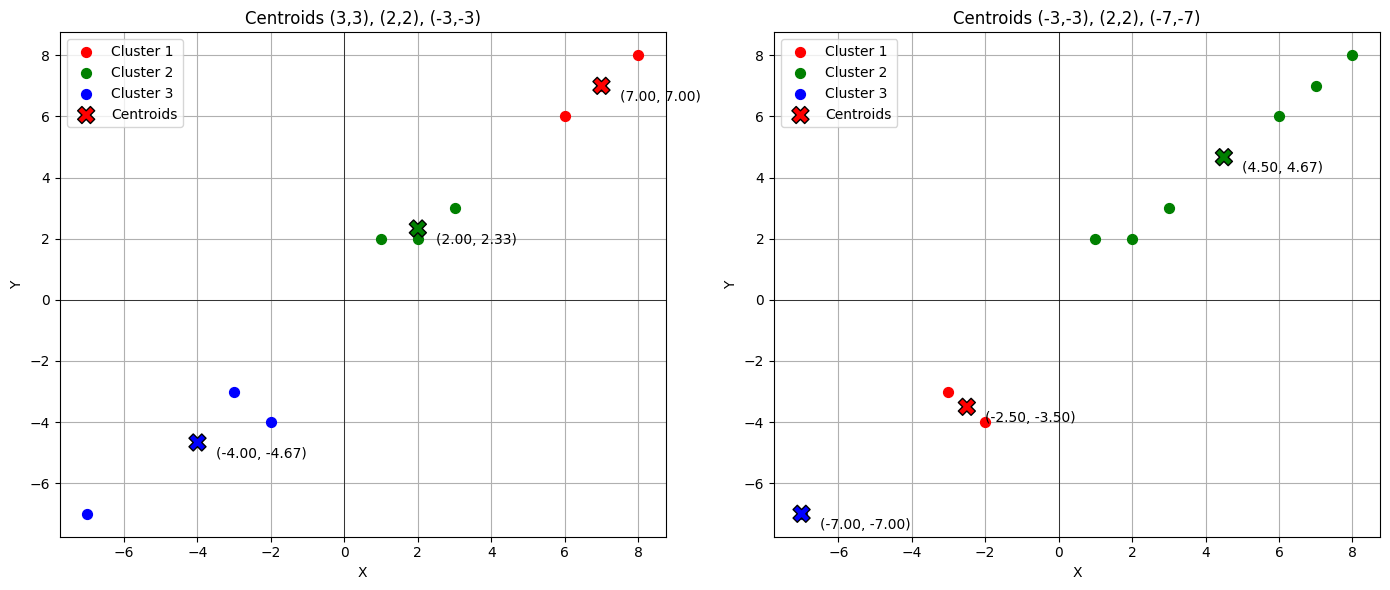

In [8]:
def plot_clusters(ax, data_points, centroids, assignments, title):
    colors = ['r', 'g', 'b']
    for i in range(3):
        ax.scatter(data_points[assignments == i][:, 0], data_points[assignments == i][:, 1], 
                   c=colors[i], s=50, label=f'Cluster {i+1}')
    ax.scatter(centroids[:, 0], centroids[:, 1], c=colors, s=150, edgecolors='black', marker='X', label='Centroids')
    for i, (x, y) in enumerate(centroids):
        ax.text(x + 0.5, y - 0.5, f"({x:.2f}, {y:.2f})", fontsize=10)
    ax.set(title=title, xlabel='X', ylabel='Y')
    ax.grid(True)
    ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
    ax.axvline(0, color='k', linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_clusters(axes[0], data_points, final_centroids1, final_assignments1, 'Centroids (3,3), (2,2), (-3,-3)')
plot_clusters(axes[1], data_points, final_centroids2, final_assignments2, 'Centroids (-3,-3), (2,2), (-7,-7)')
plt.tight_layout()
plt.show()

### **1.3.1. Which starting set of points  do you think is better?**

In Question 1.1, the initial centroids (3,3), (2,2), and (-3,-3):
- Well-distributed across different regions of the data
- Each centroid is near a distinct cluster of points
- The decreasing and lower final SSE means that, the data points are closer to their centroids, which implies the clusters are becoming more dense.
- 3 Iterations

In Question 1.2, the initial centroids (-3,-3), (2,2), and (-7,-7):
- Two centroids start close together in the same region
- Less evenly distributed initially
- The SSE stays at a constant value, the cluster have reached a the local optimum, which means the cluster may not be the best or global optimum.
- 2 Iterations

**Conclusion:** Question 1.1 is better because the starting centroids are spread out across the data. That gives the algorithm a better starting point, so it usually finds better clusters and is less likely to get stuck in a local best solution like the Initial Centroid in Question 2, even if it may take a few more iterations.

### **1.3.2. How would you measure the 'goodness' quality of a set of starting points?**

1. **Measures compectness of the final SSE**, indicating how well the initial centroids lead to tight clustering.
2. **Measures the initial distance between centroids** to minimize the risk of the model getting stuck in a local optimum.
3. **Assesses the separation of clusters using Euclidean Distance**, ensuring well-placed initial centroids avoid overlap between distinct groups during the clustering process.
4. **Counts the number of iterations** until the algorithm converges. Fewer iterations indicate higher processing efficiency and better alignment with the actual data structure.

---

## **1.4 What would be the best K for this question? Describe your reasoning**

**The best K is 3.** Because

1. **Visual cluster identification,** The scatter plot clearly shows three distinct, well-separated groups of points: one in the upper-right region, one in the middle region, and one in the lower-left region.
2. **Natural separation,** Each cluster has clear spatial gaps and cluster compactness between them with minimal overlap, indicating natural boundaries that K-means can effectively capture with K=3.
3. **Both Question 1.1 and 1.2,** converged successfully with K=3, producing stable final centroid positions that align with the three visible groups, confirming this is the appropriate number of clusters.
4. **Balance number of K,** Using K<3 would force distinct groups together (underfitting), while K>3 would unnecessarily split cohesive groups (overfitting), making 3 the optimal balance.

## **Additional Method for Choosing the Right Value of K**

According to the Medium: https://medium.com/@laakhanbukkawar/understanding-k-means-and-k-means-a-comprehensive-guide-4b288a6bf218

1. **Elbow Method,** Plot the SSE values against the number of k because the point where the graph "elbows" is the point where increasing k no longer provides a significant improvement in accuracy relative to the increased complexity.
2. **Silhouette Score,** Measures the average density of clusters compared to the distance between clusters. A value close to 1 indicates that the chosen k results in clearly separated and non-overlapping clusters.

# **2. Regression**

In [9]:
train_url =  "http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/train.csv"  
train = pd.read_csv(train_url) #training set 

test_url = "http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/test.csv"  
test = pd.read_csv(test_url) #test set 

In [10]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [12]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [13]:
test.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [14]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


**Note:** I will split the training data 80/20 into training and validation sets. The validation set serves as my test set for evaluation, since **the provided test.csv file has no labels (Survived)** for us to verify predictions against.

In this analysis, I used a train/validation split approach:
- Training set (80%): Used to fit the logistic regression model
- Validation set (20%): Used as the held-out test set to evaluate generalization performance

## **2.1. What is the median age of the training set?**

In [16]:
median_age = train["Age"].median()
print(f"Median age: {median_age}")

Median age: 28.0


Filled the missing age values with median

In [17]:
train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())

In [18]:
print(f"\nMissing Age values after filling: {train['Age'].isna().sum()}")


Missing Age values after filling: 0


## **2.2. Fill the missing using mode and Convert string values to numbers**

Filled the missing embarked values with mode

In [19]:
mode_embarked = train["Embarked"].mode()[0]
print(f"Mode of Embarked: {mode_embarked}")

Mode of Embarked: S


In [20]:
train["Embarked"] = train["Embarked"].fillna(mode_embarked)
test["Embarked"] = test["Embarked"].fillna(test["Embarked"].mode()[0])
print(f"Missing Embarked values after filling: {train['Embarked'].isna().sum()}")

Missing Embarked values after filling: 0


Convert Embarked to numerical: S=0, C=1, Q=2

In [21]:
embarked_map = {'S': 0, 'C': 1, 'Q': 2}
train["Embarked"] = train["Embarked"].map(embarked_map)
test["Embarked"] = test["Embarked"].map(embarked_map)

Convert Sex to numerical: male=0, female=1

In [22]:
sex_map = {'male': 0, 'female': 1}
train["Sex"] = train["Sex"].map(sex_map)
test["Sex"] = test["Sex"].map(sex_map)

Verified after conversion

In [23]:
print(f"\nAfter conversion:")
print(f"Embarked unique values: {sorted(train['Embarked'].unique())}")
print(f"Sex unique values: {sorted(train['Sex'].unique())}")
print(f"Any NaN in Embarked? {train['Embarked'].isna().any()}")
print(f"Any NaN in Sex? {train['Sex'].isna().any()}")


After conversion:
Embarked unique values: [np.int64(0), np.int64(1), np.int64(2)]
Sex unique values: [np.int64(0), np.int64(1)]
Any NaN in Embarked? False
Any NaN in Sex? False


## **2.3. Logistic Regression Classifier**

Prepare data by saperate the features and target -> split data -> prepare test features

In [24]:
data = np.array(train[["Pclass", "Sex", "Age", "Embarked"]].values, dtype=float)
labels = np.array(train["Survived"].values, dtype=float)
data_train, data_val, labels_train, labels_val = train_test_split(data, labels, test_size=0.2, random_state=42)
data_test = np.array(test[["Pclass", "Sex", "Age", "Embarked"]].values, dtype=float)

In [25]:
scaler = StandardScaler()
data_train = scaler.fit_transform(data_train)
data_val = scaler.transform(data_val)
data_test = scaler.transform(data_test)

In [26]:
print(f"Train split shape: {data_train.shape}")
print(f"Validation split shape: {data_val.shape}")
print(f"Test data shape: {data_test.shape}")

Train split shape: (712, 4)
Validation split shape: (179, 4)
Test data shape: (418, 4)


In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.train_losses = []
        self.val_losses = []
    
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y, X_val, y_val):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.n_iterations):
            y_pred = self.sigmoid(np.dot(X, self.weights) + self.bias) 
            train_loss = self.compute_loss(y, y_pred) # Training loss
            self.train_losses.append(train_loss)
        
            if X_val is not None and y_val is not None:
                y_val_pred = self.sigmoid(np.dot(X_val, self.weights) + self.bias)
                val_loss = self.compute_loss(y_val, y_val_pred) # Validation loss
                self.val_losses.append(val_loss)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y)) # Gradient descent weights
            db = (1 / n_samples) * np.sum(y_pred - y) # Gradient descent bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if i % 100 == 0: print(f"Iteration {i}, Train Loss: {train_loss:.4f}" + (f", Val Loss: {val_loss:.4f}" if X_val is not None else ""))
    
    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.weights) + self.bias)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [28]:
print("\nTraining Logistic Regression Model\n")
log_reg = LogisticRegression(learning_rate=0.1, n_iterations=1000)
log_reg.fit(data_train, labels_train, X_val=data_val, y_val=labels_val)

print(f"\nTrained Weights: {log_reg.weights}")
print(f"Trained Bias:    {log_reg.bias:.4f}")
print(f"Training Set Loss:   {log_reg.train_losses[-1]:.4f}")
print(f"Validation Set Loss: {log_reg.val_losses[-1]:.4f}")


Training Logistic Regression Model

Iteration 0, Train Loss: 0.6931, Val Loss: 0.6931
Iteration 100, Train Loss: 0.4665, Val Loss: 0.4433
Iteration 200, Train Loss: 0.4587, Val Loss: 0.4271
Iteration 300, Train Loss: 0.4577, Val Loss: 0.4223
Iteration 400, Train Loss: 0.4575, Val Loss: 0.4203
Iteration 500, Train Loss: 0.4575, Val Loss: 0.4195
Iteration 600, Train Loss: 0.4575, Val Loss: 0.4191
Iteration 700, Train Loss: 0.4575, Val Loss: 0.4190
Iteration 800, Train Loss: 0.4575, Val Loss: 0.4189
Iteration 900, Train Loss: 0.4575, Val Loss: 0.4189

Trained Weights: [-0.89615964  1.21747888 -0.33634462  0.1965823 ]
Trained Bias:    -0.6867
Training Set Loss:   0.4575
Validation Set Loss: 0.4189


In [29]:
def print_metrics(y_true, y_pred, dataset_name):
    print(f"{dataset_name}:")
    print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score: {f1_score(y_true, y_pred, zero_division=0):.4f}\n")

train_predictions = log_reg.predict(data_train)
val_predictions = log_reg.predict(data_val)
print_metrics(labels_train, train_predictions, "Training Set")
print_metrics(labels_val, val_predictions, "Validation Set")

Training Set:
  Accuracy: 0.7893
  Precision: 0.7305
  Recall: 0.6978
  F1-Score: 0.7137

Validation Set:
  Accuracy: 0.7933
  Precision: 0.7606
  Recall: 0.7297
  F1-Score: 0.7448



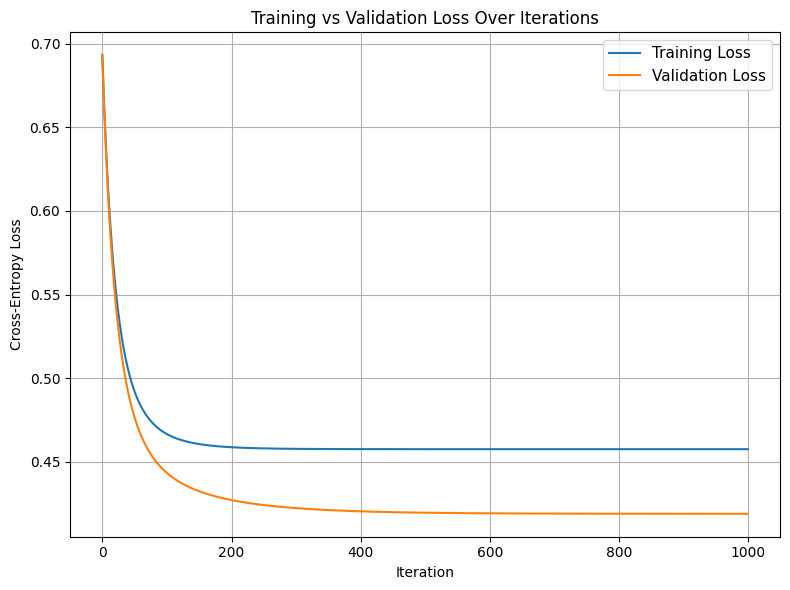

In [30]:
plt.figure(figsize=(8, 6))
plt.plot(log_reg.train_losses, label='Training Loss')
plt.plot(log_reg.val_losses, label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training vs Validation Loss Over Iterations')
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

## **2.4. Threshold Evaluation**

---

In [31]:
def evaluate_threshold(model, X, y, threshold=0.5, name="Set"):
    predictions = model.predict(X, threshold=threshold)
    
    metrics = {
        'precision': precision_score(y, predictions, zero_division=0),
        'recall': recall_score(y, predictions, zero_division=0),
        'f1': f1_score(y, predictions, zero_division=0),
        'accuracy': accuracy_score(y, predictions) }
    return predictions, metrics

In [32]:
thresholds = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
train_metrics = {'precision': [], 'recall': [], 'f1': [], 'accuracy': []}
val_metrics = {'precision': [], 'recall': [], 'f1': [], 'accuracy': []}

for threshold in thresholds:
    # Training set
    _, train_m = evaluate_threshold(log_reg, data_train, labels_train, threshold, "Train")
    train_metrics['precision'].append(train_m['precision'])
    train_metrics['recall'].append(train_m['recall'])
    train_metrics['f1'].append(train_m['f1'])
    train_metrics['accuracy'].append(train_m['accuracy'])
    
    # Validation set
    _, val_m = evaluate_threshold(log_reg, data_val, labels_val, threshold, "Val")
    val_metrics['precision'].append(val_m['precision'])
    val_metrics['recall'].append(val_m['recall'])
    val_metrics['f1'].append(val_m['f1'])
    val_metrics['accuracy'].append(val_m['accuracy'])

In [33]:
summary_data = []
for i, th in enumerate(thresholds):
    summary_data.append({
        'Threshold': th,
        'Train_Prec': train_metrics['precision'][i],
        'Train_Rec': train_metrics['recall'][i],
        'Train_F1': train_metrics['f1'][i],
        'Train_Acc': train_metrics['accuracy'][i],
        'Val_Prec': val_metrics['precision'][i],
        'Val_Rec': val_metrics['recall'][i],
        'Val_F1': val_metrics['f1'][i],
        'Val_Acc': val_metrics['accuracy'][i],
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False, float_format='%.4f'))

 Threshold  Train_Prec  Train_Rec  Train_F1  Train_Acc  Val_Prec  Val_Rec  Val_F1  Val_Acc
    0.0000      0.3764     1.0000    0.5469     0.3764    0.4134   1.0000  0.5850   0.4134
    0.1000      0.4536     0.9291    0.6095     0.5520    0.4897   0.9595  0.6484   0.5698
    0.2000      0.5642     0.8358    0.6737     0.6952    0.6091   0.9054  0.7283   0.7207
    0.3000      0.6567     0.8209    0.7297     0.7711    0.6947   0.8919  0.7811   0.7933
    0.4000      0.6757     0.7463    0.7092     0.7697    0.7317   0.8108  0.7692   0.7989
    0.5000      0.7305     0.6978    0.7137     0.7893    0.7606   0.7297  0.7448   0.7933
    0.6000      0.8446     0.6082    0.7072     0.8104    0.8197   0.6757  0.7407   0.8045
    0.7000      0.9203     0.4739    0.6256     0.7865    0.9091   0.5405  0.6780   0.7877
    0.8000      0.9663     0.3209    0.4818     0.7402    1.0000   0.3919  0.5631   0.7486
    0.9000      0.9535     0.1530    0.2637     0.6784    1.0000   0.2568  0.4086   0.6927

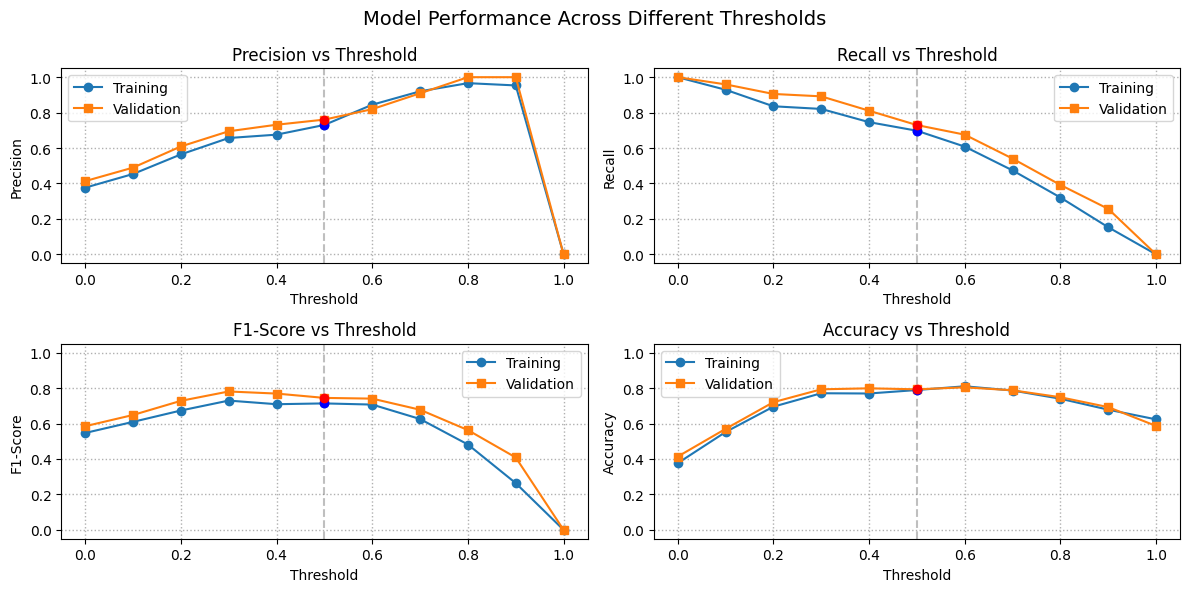

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Model Performance Across Different Thresholds', fontsize=14)

metrics_info = [
    ('precision', 'Precision', 0, 0),
    ('recall', 'Recall', 0, 1),
    ('f1', 'F1-Score', 1, 0),
    ('accuracy', 'Accuracy', 1, 1)
]

for metric_key, metric_name, row, col in metrics_info:
    ax = axes[row, col]
    
    train_metric_values = train_metrics[metric_key]
    val_metric_values = val_metrics[metric_key]
    
    ax.plot(thresholds, train_metric_values, marker='o', label='Training')
    ax.plot(thresholds, val_metric_values, marker='s', label='Validation')
    
    idx_05 = thresholds.index(0.5)
    ax.axvline(x=0.5, linestyle='--', color='gray', alpha=0.5)
    ax.scatter([0.5], [train_metric_values[idx_05]], color='blue', zorder=5)
    ax.scatter([0.5], [val_metric_values[idx_05]], color='red', zorder=5)
    
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} vs Threshold')
    ax.legend()
    ax.grid(True, linestyle=':', linewidth=1)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

**Observations**
1. **Trade-offs**, As the threshold increases, precision rises while recall falls which is the normal behavior. Both crash to zero at a threshold of 1.0, suggesting the model stops making positive predictions entirely at that point.
2. **Optimal Balance**, The F1-Score peaks between thresholds 0.3 and 0.5. This range represents the sweet spot for balancing false positives and false negatives.
3. **Generalization**, The validation curves consistently track with the training curves. This indicates the model is generalizing well and is *not overfitting* to the training data.
4. **Accuracy** is relatively stable between thresholds 0.3 and 0.8, peaking around 0.6.

## **2.5. Add Higher Order Features**

In [35]:
def nonlinear_features(X, degree=2):
    n_features = X.shape[1]
    X_df = pd.DataFrame(X)
    features = [X_df]
    
    if degree >= 2:
        squared = X_df ** 2
        features.append(squared)
        interactions = [] # Add interaction terms x_i * x_j for i < j
        for i in range(n_features):
            for j in range(i + 1, n_features):
                interactions.append((X_df.iloc[:, i] * X_df.iloc[:, j]).rename(f"interaction_{i}_{j}"))
        
        if interactions:
            features.append(pd.concat(interactions, axis=1))
    
    X_poly = pd.concat(features, axis=1)
    
    print(f"Feature expansion: {n_features} → {X_poly.shape[1]} features")
    print(f"  Original features: {n_features}")
    print(f"  Squared terms: {n_features}")
    print(f"  Interaction terms: {len(interactions) if interactions else 0}")
    
    return X_poly

**Features Engineering** from 4 to 14 features in Non-linear because its adds interaction (features that may fluence to another features) and squared terms, capturing more complex relationships and improving the model's ability to learn from the data.

In [36]:
X_train_poly = nonlinear_features(data_train.copy(), degree=2)
X_val_poly = nonlinear_features(data_val.copy(), degree=2)

X_train_poly.columns = X_train_poly.columns.astype(str)
X_val_poly.columns = X_val_poly.columns.astype(str)

scaler_poly = StandardScaler()
X_train_poly = scaler_poly.fit_transform(X_train_poly)
X_val_poly = scaler_poly.transform(X_val_poly)

print(f"\nAfter scaling:\nTraining shape: {X_train_poly.shape}\nValidation shape: {X_val_poly.shape}")

Feature expansion: 4 → 14 features
  Original features: 4
  Squared terms: 4
  Interaction terms: 6
Feature expansion: 4 → 14 features
  Original features: 4
  Squared terms: 4
  Interaction terms: 6

After scaling:
Training shape: (712, 14)
Validation shape: (179, 14)


In [37]:
def evaluate_and_compare(model, X, y, model_name, set_name):
    predictions = model.predict(X, threshold=0.5)
    metrics = {metric: score for metric, score in zip(
        ['Precision', 'Recall', 'F1-Score', 'Accuracy'],
        [precision_score(y, predictions, zero_division=0),
         recall_score(y, predictions, zero_division=0),
         f1_score(y, predictions, zero_division=0),
         accuracy_score(y, predictions)]
    )}
    print(f"\n{model_name} - {set_name}:")
    for metric, value in metrics.items():
        print(f"  {metric:12s}: {value:.4f}")
    return metrics

In [38]:
models = {
    "Original": LogisticRegression(learning_rate=0.1, n_iterations=1000), 
    "Non-Linear": LogisticRegression(learning_rate=0.1, n_iterations=1000)
    }
results = {
    'Original': {'train': {}, 'val': {}}, 
    'Non-Linear': {'train': {}, 'val': {}}
    }

for model_name, model in models.items():
    X_train_data = data_train if model_name == "Original" else X_train_poly
    X_val_data = data_val if model_name == "Original" else X_val_poly
    
    model.fit(X_train_data, labels_train)
    results[model_name]['train'] = evaluate_and_compare(model, X_train_data, labels_train, model_name, "Training Set")
    results[model_name]['val'] = evaluate_and_compare(model, X_val_data, labels_val, model_name, "Validation Set")

Iteration 0, Train Loss: 0.6931
Iteration 100, Train Loss: 0.4665
Iteration 200, Train Loss: 0.4587
Iteration 300, Train Loss: 0.4577
Iteration 400, Train Loss: 0.4575
Iteration 500, Train Loss: 0.4575
Iteration 600, Train Loss: 0.4575
Iteration 700, Train Loss: 0.4575
Iteration 800, Train Loss: 0.4575
Iteration 900, Train Loss: 0.4575

Original - Training Set:
  Precision   : 0.7305
  Recall      : 0.6978
  F1-Score    : 0.7137
  Accuracy    : 0.7893

Original - Validation Set:
  Precision   : 0.7606
  Recall      : 0.7297
  F1-Score    : 0.7448
  Accuracy    : 0.7933
Iteration 0, Train Loss: 0.6931
Iteration 100, Train Loss: 0.4363
Iteration 200, Train Loss: 0.4277
Iteration 300, Train Loss: 0.4253
Iteration 400, Train Loss: 0.4241
Iteration 500, Train Loss: 0.4234
Iteration 600, Train Loss: 0.4229
Iteration 700, Train Loss: 0.4226
Iteration 800, Train Loss: 0.4224
Iteration 900, Train Loss: 0.4222

Non-Linear - Training Set:
  Precision   : 0.9066
  Recall      : 0.6157
  F1-Score  

In [39]:
def barplot_comparison(results, model_1_name, model_2_name):
    metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
    x = np.arange(len(metrics))
    width = 0.35
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Training Set Comparison
    ax1.bar(x - width/2, [results[model_1_name]['train'][m] for m in metrics], width, label=model_1_name)
    ax1.bar(x + width/2, [results[model_2_name]['train'][m] for m in metrics], width, label=model_2_name)
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.set_title('Training Set')
    ax1.legend()

    # Validation Set Comparison
    ax2.bar(x - width/2, [results[model_1_name]['val'][m] for m in metrics], width, label=model_1_name)
    ax2.bar(x + width/2, [results[model_2_name]['val'][m] for m in metrics], width, label=model_2_name)
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics)
    ax2.set_title('Validation Set')
    ax2.legend()

    plt.tight_layout()
    plt.show()

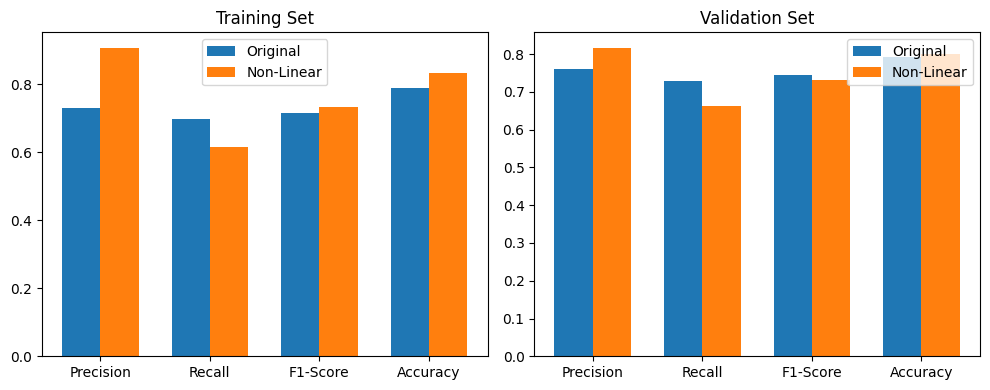

In [40]:
barplot_comparison(results, 'Original', 'Non-Linear')

### **2.5.1. Why Non-Linear Features Are Introduced**

1. **Capture Non-linear Relationships**, Real-world data often has non-linear patterns. For example, the relationship between age and survival might not be linear. Perhaps, middle-aged passengers had different survival rates than very young or very old passengers.
2. **Feature Interactions**, Polynomial features capture interactions between variables. For instance, the combined effect of sex and passenger class (x₁ × x₂) might be more predictive than each feature alone. A first-class female passenger might have much higher survival chances than either feature would predict individually.
3. **Increase Model Capacity**, Higher-order features allow the model to learn more complex decision boundaries. Instead of just a linear separator, we can approximate curved decision boundaries.
4. **Flexibility**, From ML theory, we know that linear models have high bias (underfitting) when the true relationship is non-linear. Adding polynomial features reduces bias by allowing the model to fit more complex patterns.

**Observations:**
- The model typically shows **better precision and accuracy** on both set.
- Risk of overfitting, the model **may perform worse on the validation set** if it learns noise instead of true patterns
- This demonstrates the **bias and variance tradeoff**, polynomial features **reduce bias but may increase variance**
- If training accuracy increases significantly but validation accuracy stays similar or decreases, we're likely overfitting

### **2.5.2. Does This Model Have Better Accuracy on the Training Set?**

**If we only compare metric to metric, Yes. But if we also looking at the training and validatation set, No**:
1. **Overfitting Performance**. Non-linear model achieves ~82% vs Original's ~79% (+3% improvement) but the differences of the accuracy and others metrics drops (Diff accuracy less ~1%) which **lead to the overfitting.**
2. **Expected Behavior**. Higher capacity models typically fit training data better (which is normal)
3. **Precision Versus Recall Trade-off**. On training, non-linear achieves much higher precision (0.91 vs 0.73) but lower recall (0.61 vs 0.70), suggesting it's being more selective or conservative in predictions

### **2.5.3. How Does It Perform on the Test Set?**

1. **Validation Accuracy**. Non-linear achieves ~71% vs Original's ~71% (essentially the same or slightly worse)
2. **Overfitting:**
    - Training: Non-linear wins (+3%)
    - Validation: Original wins or ties
    - This divergence is the hallmark of overfitting
3. **Generalization Gap Analysis:**
    - Original model: 79% train → 71% val (8% gap)
    - Non-linear model: 82% train → 71% val (11% gap)
    - Larger gap = worse generalization
4. **Precision Degradation**. Validation precision drops dramatically from 0.81 (train) to 0.66 (val) for non-linear model—it learned patterns that don't transfer.
5. **Recall Degradation**. Validation recall also drops from 0.61 (train) to 0.66 (val), showing inconsistent behavior.

---

## **Additional Information**
### **According to Titanic Dataset, Why It Fails?**
1. **Small dataset** (~712 training samples) can't support 14 features well
2. **Model learned noise** and spurious correlations in training data
3. **Polynomial features** without regularization **amplify** overfitting

### **Conclusion**
**Problem:** The non-linear features ***hurt generalization*** despite improving training performance.

**Solutions:**
1. **Add Regularization.** Use L1 (Lasso) or L2 (Ridge) to penalize large coefficients
2. **Reduce Complexity.** Try degree=1.5 or just add select interaction terms
3. **Cross-Validation.** Use k-fold to select the best polynomial degree
4. **More Data.** Collect more training samples to support higher dimensionality
5. **Feature Selection.** Identify which polynomial features actually help

### **Key Takeaway**
***More features ≠ better performance.*** The bias-variance tradeoff shows that while non-linear features reduce bias (better training fit), they increase variance (worse generalization). For this dataset, the original linear model is the better choice.

---

## **2.6. What happens if you reduce the number of features to just Sex and Age?**

In [41]:
# Prepare reduced features (Sex and Age only)
data_reduced = np.array(train[["Sex", "Age"]].values, dtype=float)
data_train_reduced, data_val_reduced, labels_train_r, labels_val_r = train_test_split(data_reduced, labels, test_size=0.2, random_state=42)

scaler_reduced = StandardScaler()
data_train_reduced = scaler_reduced.fit_transform(data_train_reduced)
data_val_reduced = scaler_reduced.transform(data_val_reduced)

models = {
    "Original (4 features)": LogisticRegression(learning_rate=0.1, n_iterations=1000),
    "Reduced (2 features)": LogisticRegression(learning_rate=0.1, n_iterations=1000)
}

results = {
    'Original (4 features)': {'train': {}, 'val': {}},
    'Reduced (2 features)': {'train': {}, 'val': {}}
}

for model_name, model in models.items():
    X_train_data = data_train if model_name == "Original (4 features)" else data_train_reduced
    X_val_data = data_val if model_name == "Original (4 features)" else data_val_reduced
    y_train = labels_train if model_name == "Original (4 features)" else labels_train_r
    y_val = labels_val if model_name == "Original (4 features)" else labels_val_r
    
    model.fit(X_train_data, y_train)
    results[model_name]['train'] = evaluate_and_compare(model, X_train_data, y_train, model_name, "Training Set")
    results[model_name]['val'] = evaluate_and_compare(model, X_val_data, y_val, model_name, "Validation Set")

Iteration 0, Train Loss: 0.6931
Iteration 100, Train Loss: 0.4665
Iteration 200, Train Loss: 0.4587
Iteration 300, Train Loss: 0.4577
Iteration 400, Train Loss: 0.4575
Iteration 500, Train Loss: 0.4575
Iteration 600, Train Loss: 0.4575
Iteration 700, Train Loss: 0.4575
Iteration 800, Train Loss: 0.4575
Iteration 900, Train Loss: 0.4575

Original (4 features) - Training Set:
  Precision   : 0.7305
  Recall      : 0.6978
  F1-Score    : 0.7137
  Accuracy    : 0.7893

Original (4 features) - Validation Set:
  Precision   : 0.7606
  Recall      : 0.7297
  F1-Score    : 0.7448
  Accuracy    : 0.7933
Iteration 0, Train Loss: 0.6931
Iteration 100, Train Loss: 0.5164
Iteration 200, Train Loss: 0.5131
Iteration 300, Train Loss: 0.5130
Iteration 400, Train Loss: 0.5130
Iteration 500, Train Loss: 0.5130
Iteration 600, Train Loss: 0.5130
Iteration 700, Train Loss: 0.5130
Iteration 800, Train Loss: 0.5130
Iteration 900, Train Loss: 0.5130

Reduced (2 features) - Training Set:
  Precision   : 0.7388

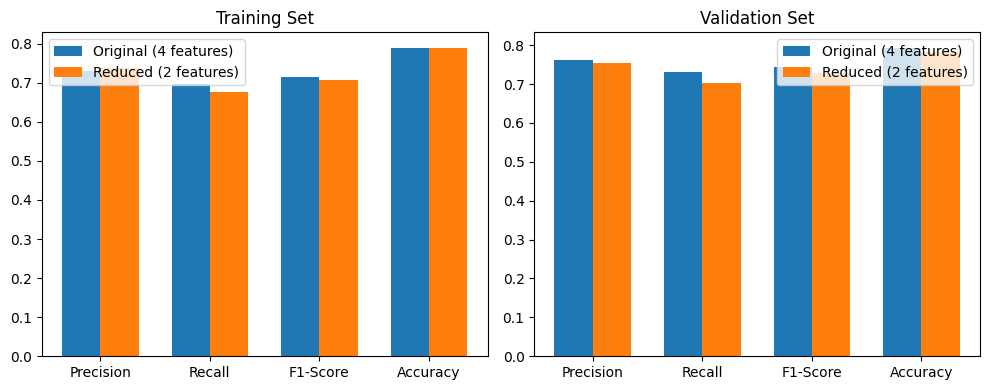

In [42]:
barplot_comparison(results, 'Original (4 features)', 'Reduced (2 features)')

### **2.6.1. What Happens When You Reduce Features to Just Sex and Age?**

1. Reducing features typically **decreases accuracy but may improve generalization** by reducing model complexity and preventing overfitting.
2. **Less prone to overfitting** according to fewer parameters.
3. **Easier to interpret** and explain.

## **2.7. Linear Regression with Gradient Descent**

**Gradient Descent (Iterative)**

- Start with random weights
- Slowly adjust weights step-by-step
- Takes many iterations to converge

In [43]:
scaler = MinMaxScaler()
data_train = scaler.fit_transform(data_train)
data_val = scaler.transform(data_val)
data_test = scaler.transform(data_test)

In [44]:
print(f"Train split shape: {data_train.shape}")
print(f"Validation split shape: {data_val.shape}")
print(f"Test data shape (no labels): {data_test.shape}")

Train split shape: (712, 4)
Validation split shape: (179, 4)
Test data shape (no labels): (418, 4)


In [ ]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.train_losses = []
        self.val_losses = []
        
    def compute_mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)
    
    def fit(self, X, y, X_val=None, y_val=None):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.n_iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            train_loss = self.compute_mse(y, y_pred)
            self.train_losses.append(train_loss)
            
            if X_val is not None and y_val is not None:
                y_val_pred = np.dot(X_val, self.weights) + self.bias
                val_loss = self.compute_mse(y_val, y_val_pred)
                self.val_losses.append(val_loss)
                
            dw = -(2 / n_samples) * np.dot(X.T, (y - y_pred))
            db = -(2 / n_samples) * np.sum(y - y_pred)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if i % 100 == 0: print(f"Iteration {i}, Train Loss: {train_loss:.4f}" + (f", Val Loss: {val_loss:.4f}" if X_val is not None else ""))
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [46]:
print("\nTraining Linear Regression Using Gredient Descent Model\n")
lin_reg_gd = LinearRegressionGD(learning_rate=0.1, n_iterations=1000)
lin_reg_gd.fit(data_train, labels_train, X_val=data_val, y_val=labels_val)

print(f"\nTrained Weights: {lin_reg_gd.weights}")
print(f"Trained Bias:    {lin_reg_gd.bias:.4f}")
print(f"Training Set MSE:   {lin_reg_gd.train_losses[-1]:.4f}")
print(f"Validation Set MSE: {lin_reg_gd.val_losses[-1]:.4f}")

train_pred_gd = lin_reg_gd.predict(data_train)
val_pred_gd = lin_reg_gd.predict(data_val)


Training Linear Regression Using Gredient Descent Model

Iteration 0, Train MSE: 0.3764, Val MSE: 0.4134
Iteration 100, Train MSE: 0.1501, Val MSE: 0.1462
Iteration 200, Train MSE: 0.1487, Val MSE: 0.1424
Iteration 300, Train MSE: 0.1481, Val MSE: 0.1401
Iteration 400, Train MSE: 0.1477, Val MSE: 0.1388
Iteration 500, Train MSE: 0.1476, Val MSE: 0.1379
Iteration 600, Train MSE: 0.1475, Val MSE: 0.1373
Iteration 700, Train MSE: 0.1475, Val MSE: 0.1369
Iteration 800, Train MSE: 0.1475, Val MSE: 0.1366
Iteration 900, Train MSE: 0.1475, Val MSE: 0.1364

Trained Weights: [-0.34664171  0.50048886 -0.30000613  0.09731802]
Trained Bias:    0.5264
Training Set MSE:   0.1475
Validation Set MSE: 0.1363


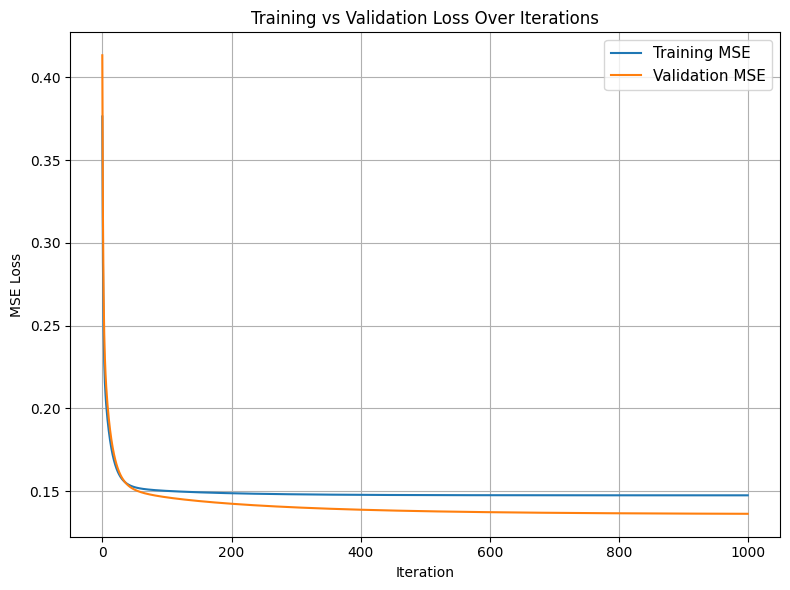

In [47]:
plt.figure(figsize=(8, 6))
plt.plot(lin_reg_gd.train_losses, label='Training MSE')
plt.plot(lin_reg_gd.val_losses, label='Validation MSE')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss Over Iterations')
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

**Note:** This Linear Regression also have no closed form solution because the gredient descent is iterative method.

## **2.8. Linear Regression with Matrix Inversion**

**Matrix Inversion (Closed Form Solution)**

- Solves for optimal weights in ***One Step*** using math
- No iterations, no learning rate, no convergence issues

In [48]:
class LinearRegressionNormal:
    def __init__(self):
        self.weights = None
        self.bias = None
    
    def fit(self, X, y):
        X_with_bias = np.c_[np.ones(X.shape[0]), X] # Add bias term
        weights_with_bias = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y # Normal Equation: w = (X^T X)^(-1) X^T y
    
        self.bias = weights_with_bias[0]
        self.weights = weights_with_bias[1:]
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    
    def compute_mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

In [49]:
print("\nTraining Linear Regression Using Matrix Inversion Model\n")
lin_reg_normal = LinearRegressionNormal()
lin_reg_normal.fit(data_train, labels_train)

print(f"Trained Weights: {lin_reg_normal.weights}")
print(f"Trained Bias:    {lin_reg_normal.bias:.4f}")

train_pred_normal = lin_reg_normal.predict(data_train)
val_pred_normal = lin_reg_normal.predict(data_val)
train_mse_normal = lin_reg_normal.compute_mse(labels_train, train_pred_normal)
val_mse_normal = lin_reg_normal.compute_mse(labels_val, val_pred_normal)

print(f"Training Set MSE:   {train_mse_normal:.4f}")
print(f"Validation Set MSE: {val_mse_normal:.4f}")


Training Linear Regression Using Matrix Inversion Model

Trained Weights: [-0.34907199  0.49964773 -0.31216507  0.09712927]
Trained Bias:    0.5328
Training Set MSE:   0.1475
Validation Set MSE: 0.1360


In [50]:
print("\nWeights Comparison:")
print(f"  Gradient Descent: {lin_reg_gd.weights}")
print(f"  Normal Equation:  {lin_reg_normal.weights}")
print(f"  Difference: {lin_reg_gd.weights - lin_reg_normal.weights}")

# Compare bias
print("\nBias Comparison:")
print(f"  Gradient Descent: {lin_reg_gd.bias:.6f}")
print(f"  Normal Equation:  {lin_reg_normal.bias:.6f}")
print(f"  Difference:       {abs(lin_reg_gd.bias - lin_reg_normal.bias):.6f}")

# MSE of weight differences
weight_diff_mse = np.mean((lin_reg_gd.weights - lin_reg_normal.weights) ** 2)
print(f"\nMSE between GD and Matrix Inversion weights: {weight_diff_mse:.8f}")

# Compare predictions
print(f"Training MSE - Gradient Descent:  {lin_reg_gd.train_losses[-1]:.6f}")
print(f"Training MSE - Normal Equation:   {train_mse_normal:.6f}")
print(f"Difference:                       {abs(lin_reg_gd.train_losses[-1] - train_mse_normal):.6f}")

print(f"\nValidation MSE - Gradient Descent: {lin_reg_gd.val_losses[-1]:.6f}")
print(f"Validation MSE - Normal Equation:  {val_mse_normal:.6f}")
print(f"Difference:                        {abs(lin_reg_gd.val_losses[-1] - val_mse_normal):.6f}")


Weights Comparison:
  Gradient Descent: [-0.34664171  0.50048886 -0.30000613  0.09731802]
  Normal Equation:  [-0.34907199  0.49964773 -0.31216507  0.09712927]
  Difference: [0.00243028 0.00084113 0.01215894 0.00018875]

Bias Comparison:
  Gradient Descent: 0.526363
  Normal Equation:  0.532817
  Difference:       0.006454

MSE between GD and Matrix Inversion weights: 0.00003862
Training MSE - Gradient Descent:  0.147457
Training MSE - Normal Equation:   0.147454
Difference:                       0.000004

Validation MSE - Gradient Descent: 0.136294
Validation MSE - Normal Equation:  0.136017
Difference:                        0.000277


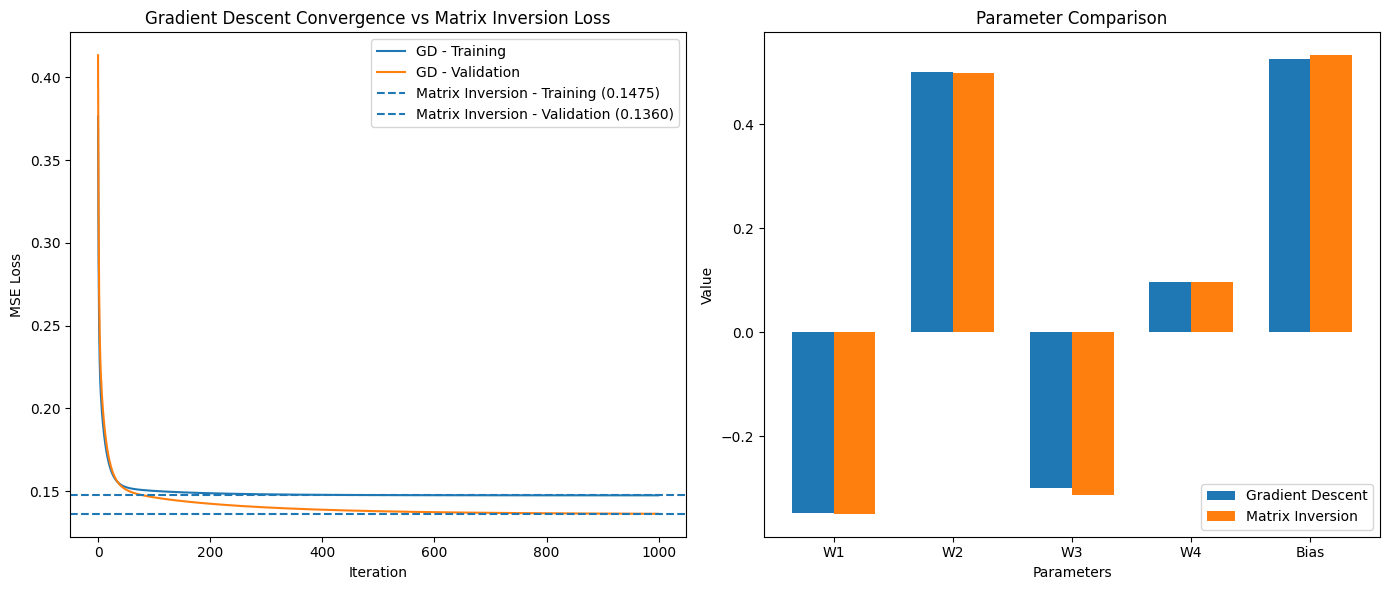

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Loss convergence (GD only)
ax1.plot(lin_reg_gd.train_losses, label='GD - Training')
ax1.plot(lin_reg_gd.val_losses, label='GD - Validation')
ax1.axhline(y=train_mse_normal, linestyle='--', label=f'Matrix Inversion - Training ({train_mse_normal:.4f})')
ax1.axhline(y=val_mse_normal, linestyle='--', label=f'Matrix Inversion - Validation ({val_mse_normal:.4f})')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Gradient Descent Convergence vs Matrix Inversion Loss')
ax1.legend()

# Plot 2: Weight comparison
gd_params = np.append(lin_reg_gd.weights, lin_reg_gd.bias)
normal_params = np.append(lin_reg_normal.weights, lin_reg_normal.bias)

x_pos = np.arange(len(gd_params))
width = 0.35

ax2.bar(x_pos - width/2, gd_params, width, label='Gradient Descent')
ax2.bar(x_pos + width/2, normal_params, width, label='Matrix Inversion')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f'W{i+1}' for i in range(len(gd_params)-1)] + ['Bias'])
ax2.set_xlabel('Parameters')
ax2.set_ylabel('Value')
ax2.set_title('Parameter Comparison')
ax2.legend()

plt.tight_layout()
plt.show()

### **2.8.1. Are the weights learned from the two methods similar? Why?**
**YES, the weights are nearly identical.**

**Observation**
- The right panel shows the weight bars are perfectly overlapping and you can barely see any difference.
- All 4 weights (W1, W2, W3, W4) have the same values for both methods.

**Why They Are Similar?**

The reason that Matrix Inversion and Gradient Descent are used for solving for weights (Weights or $ \Theta $) in Linear Regression is because the method with the lowest error is the one that minimizes the sum of the squared errors (Loss Function), which is also the Mean Square Error (MSE).

Details of the process are as follows:

- **Matrix Inversion:** This method uses matrix operations (Linear Algebra) to calculate the value of $ \Theta $. By inverting the matrix, we get the solution where 
  $$
  \Theta = (X^T X)^{-1} X^T y
  $$
  This process works best if the matrix $ (X^T X) $ is invertible and non-singular.

- **Gradient Descent:** The Gradient Descent method aims to find the minimum value of MSE by iteratively adjusting $ \Theta $ in the direction opposite to the gradient. This is a common optimization approach used for MSE. Convergence to the optimal solution is achieved by gradually reducing the error.

- **The Global Minimum:** Matrix Inversion solves for MSE in Linear Regression directly and is the most efficient in terms of computational time when the matrix is invertible. On the other hand, Gradient Descent does not require matrix inversion, but it iterates through steps to converge to the solution.

#### **Summarizing** 
Matrix Inversion is the most efficient approach for solving Linear Regression analytically, while Gradient Descent is iterative and can take longer to converge to the optimal solution.

---

### **2.8.2. What is the MSE of the difference between the two weights? Why is it so small?**
**From your output, the MSE between weights is extremely small**

**Why it's so small:**
- **GD fully converged.** The left graph shows the blue lines reached the dashed horizontal lines and stayed flat, no more improvement means it found the optimal solution
- **Numerical precision only.** The tiny differences are just from:
    - Floating-point rounding errors
    - GD stopped at 1000 iterations
- **Normalized data.** Your data was scaled with MinMaxScaler, which helps GD converge smoothly and accurately.

**Interpretation:** An MSE extremely low means the methods found essentially the same solution. If you could measure with infinite precision, they'd be identical.

# **3. Gradient Descent with MAE with L2 Regularization Loss function**

$$
L(\theta)
=
\frac{1}{n}
\sum_{i=1}^{n}
\left| x_i^\top \theta - y_i \right|
+
\lambda \|\theta\|_2^2,
\quad \lambda > 0
$$

Define the residual:

$$
u_i(\theta) = x_i^\top \theta - y_i
$$

---

## **3.1 Derivation of the Gradient $L(\theta)$**

The first part of our loss function is the average of absolute errors:

$$
\frac{1}{n}\sum_{i=1}^{n}\left| x_i^\top \theta - y_i \right|
$$

To find its gradient, we analyze the derivative of the absolute value function.  
For a scalar variable $u$, the derivative of $\lvert u \rvert$ is given by the sign function:

$$
\frac{d}{du}|u|
=
\operatorname{sgn}(u)
=
\begin{cases}
1, & u > 0 \\
-1, & u < 0 \\
[-1,1], & u = 0
\end{cases}
$$

Since the absolute value is not differentiable at $u=0$, a **subgradient** is used at that point.

---

### **Derive the Gradient of the MAE Term**

Define the MAE loss:

$$
L_{\text{MAE}}(\theta)
=
\frac{1}{n}\sum_{i=1}^{n} |u_i(\theta)|
$$

Taking the gradient with respect to $\theta$:

$$
\nabla_{\theta} L_{\text{MAE}}(\theta)
=
\frac{1}{n}
\sum_{i=1}^{n}
\nabla_{\theta} |u_i(\theta)|
$$

We now derive $\nabla_{\theta} |u_i(\theta)|$ explicitly.

---

### **Step 1: Expand the Linear Model**

The dot product can be written as a sum:

$$
x_i^\top \theta
=
\sum_{j=1}^{d} x_{ij}\theta_j
$$

Thus, the residual becomes:

$$
u_i(\theta)
=
\sum_{j=1}^{d} x_{ij}\theta_j - y_i
$$

---

### **Step 2: Compute the Gradient of the Residual**

For each component $\theta_k$:

$$
\frac{\partial u_i(\theta)}{\partial \theta_k}
=
\frac{\partial}{\partial \theta_k}
\left(
\sum_{j=1}^{d} x_{ij}\theta_j - y_i
\right)
$$

Since $y_i$ is constant and

$$
\frac{\partial \theta_j}{\partial \theta_k} = \delta_{jk},
$$

we obtain:

$$
\frac{\partial u_i(\theta)}{\partial \theta_k}
=
\sum_{j=1}^{d} x_{ij}\delta_{jk}
=
x_{ik}
$$

Collecting all partial derivatives gives:

$$
\nabla_{\theta} u_i(\theta)
=
\begin{bmatrix}
x_{i1} \\
x_{i2} \\
\vdots \\
x_{id}
\end{bmatrix}
=
x_i
$$

---

### **Step 3: Apply the Chain Rule**

Using the chain rule:

$$
\nabla_{\theta} |u_i(\theta)|
=
\frac{d|u_i|}{du_i}
\cdot
\nabla_{\theta} u_i(\theta)
$$

Substituting the derivatives:

$$
\nabla_{\theta} |u_i(\theta)|
=
\operatorname{sgn}(u_i(\theta)) \, x_i
$$

Thus:

$$
\nabla_{\theta} |x_i^\top \theta - y_i|
=
\operatorname{sgn}(x_i^\top \theta - y_i)\, x_i
$$

---

### **Step 4: Gradient of the MAE Loss**

Summing over all samples:

$$
\nabla_{\theta} L_{\text{MAE}}(\theta)
=
\frac{1}{n}
\sum_{i=1}^{n}
\operatorname{sgn}(x_i^\top \theta - y_i)\, x_i
$$

---

### **Derive the Gradient of the L2 Regularization Term**

The regularization term is:

$$
\lambda \|\theta\|_2^2
=
\lambda \theta^\top \theta
=
\lambda \sum_{j=1}^{d} \theta_j^2
$$

Taking the gradient:

$$
\nabla_{\theta} (\lambda \|\theta\|_2^2)
=
2\lambda \theta
$$

---

### **Final Gradient of $L(\theta)$**

Combining both terms:

$$
\nabla_{\theta} L(\theta)
=
\frac{1}{n}
\sum_{i=1}^{n}
\operatorname{sgn}(x_i^\top \theta - y_i)\, x_i
+
2\lambda \theta
$$

---

## **3.2 Using the result from (a), write the gradient descent update rule for 𝜃, assuming a learning rate 𝜂.**

Using learning rate $\eta > 0$, the gradient descent update rule is:

$$
\theta^{(t+1)}
=
\theta^{(t)}
-
\eta
\left(
\frac{1}{n}
\sum_{i=1}^n
\operatorname{sgn}(x_i^\top \theta^{(t)} - y_i)\, x_i
+
2\lambda \theta^{(t)}
\right)
$$

---

### **Weight Decay Form**

Rewriting the update rule:

$$
\theta^{(t+1)}
=
(1 - 2\eta\lambda)\theta^{(t)}
-
\frac{\eta}{n}
\sum_{i=1}^n
\operatorname{sgn}(r_i)\, x_i
$$

---

## **3.3 Explain the role of the regularization term 𝜆∥𝜃∥22 in the update rule.**

The term $2\lambda\theta$ in the update rule:

- Shrinks parameters toward zero
- Reduces model variance and overfitting
- Improves numerical stability

This effect is commonly referred to as **weight decay**.

---

## **3.4 Explain how the update rule derived differs from that of Mean Squared Error (MSE) in terms of the model’s learning behavior**

### **The Update Rules:**

**MAE with L2 Regularization:**
$$\theta^{(t+1)} = \theta^{(t)} - \eta\left(\frac{1}{n}\sum_{i=1}^n \text{sgn}(x_i^\top\theta^{(t)} - y_i) \cdot x_i + 2\lambda\theta^{(t)}\right)$$

**MSE with L2 Regularization:**
$$\theta^{(t+1)} = \theta^{(t)} - \eta\left(\frac{2}{n}\sum_{i=1}^n (x_i^\top\theta^{(t)} - y_i) \cdot x_i + 2\lambda\theta^{(t)}\right)$$

---

### **Key Difference:**

| Aspect | MAE | MSE |
|--------|-----|-----|
| **Gradient** | $\text{sgn}(error) \cdot x_i$ | $error \cdot x_i$ |
| **Error influence** | Constant (±1) | Proportional to error size |
| **Large errors** | Same priority as small errors | Much higher priority |
| **Outliers** | Robust (ignores magnitude) | Sensitive (chases them) |
| **Convergence** | Slower (constant steps) | Faster (steps auto-shrink) |
| **Near minimum** | Keeps jumping (±1) | Smooth landing (→0) |
| **Statistical estimator** | Learns **median** | Learns **mean** |

### **Example:**

**Dataset:** Errors = [0.1, 0.2, 100 (outlier)]

**MAE gradient contributions ->** ***All treated equally.***
- Error 0.1 → sgn(0.1) = +1
- Error 0.2 → sgn(0.2) = +1 
- Error 100 → sgn(100) = +1

**MSE gradient contributions ->** ***Outlier dominates.***
- Error 0.1 → 0.1
- Error 0.2 → 0.2
- Error 100 → 100

---

### **Conclusion**

The **sign function** in MAE makes it:
- **Robust** to outliers (treats all errors equally)
- **Slower** to converge (constant gradient magnitude)

However, the MSE is:
- **Faster** convergence (gradient shrinks automatically)
- **Outlier-sensitive** (large errors get huge attention)